# DeepFund Trading Performance Analysis

Comprehensive analysis of DeepFund AI trading strategy results from SQLite database.

**Analysis Date**: March 1, 2026  
**Experiment**: dev configuration

## 1. Setup

In [ ]:
# Add project directories to Python path (so imports work without installing package)
import sys
import os
from pathlib import Path

project_root = Path().absolute().parent.parent
decision_making_dir = project_root / "decision_making"

# Add both directories to path
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(decision_making_dir))

# Change working directory to decision_making (needed for relative imports in existing code)
os.chdir(decision_making_dir)

# Standard imports
import json
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

# DeepFund imports (with importlib reload to get latest changes)
import importlib
import decision_making.analysis.performance as perf_module
import decision_making.analysis.queries as query_module
importlib.reload(perf_module)
importlib.reload(query_module)

from decision_making.analysis.performance import (
    calculate_annualized_return,
    calculate_buy_hold_benchmark,
    calculate_max_drawdown,
    calculate_portfolio_benchmark,
    calculate_realized_pnl,
    calculate_sharpe_ratio,
    extract_ticker_positions,
    get_portfolio_timeseries,
)
from decision_making.analysis.queries import (
    check_data_quality,
    get_all_decisions,
    get_all_signals,
    get_decision_summary,
    get_experiment_metadata,
    get_signal_summary,
)
from decision_making.database.sqlite_helper import SQLiteDB

# Plotting style (matching existing EDA notebooks)
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

# Color scheme
COLORS = {
    "TSLA": "#E31E24",
    "BTC": "#F7931A",
    "portfolio": "#2E86AB",
    "benchmark": "#A23B72",
    "buy": "#28A745",
    "sell": "#DC3545",
    "hold": "#6C757D",
    "bullish": "#90EE90",
    "bearish": "#F08080",
    "neutral": "#FFE4B5",
}

print("Setup complete!")
print(f"Working directory: {os.getcwd()}")

## 2. Load Data from Database

In [2]:
config_name = "dev_max"

# Initialize database connection
db = SQLiteDB()
config_id = db.get_config_id_by_name(config_name)

if not config_id:
    raise ValueError(f"Configuration '{config_name}' not found in database")

print(f"Config ID: {config_id}")

Config ID: 2be65677-63f6-4f5b-b9e2-5a10ea2ed0e6


In [3]:
# Check data quality
data_quality = check_data_quality(db, config_id)

if data_quality["corrupted_records"] > 0:
    print("=" * 80)
    print("⚠️  DATA QUALITY WARNING")
    print("=" * 80)
    print(
        f"Corrupted records found: {data_quality['corrupted_records']} / {data_quality['total_records']} ({data_quality['corruption_percentage']:.1f}%)"
    )
    print(f"First corrupted date: {data_quality['first_corrupted_date']}")
    print(f"\nAnalysis will use only valid data from {data_quality['first_valid_date']} to {data_quality['last_valid_date']}")
    print("=" * 80)
    print()

# Load experiment metadata
metadata = get_experiment_metadata(db, config_id)

print("=" * 60)
print("EXPERIMENT METADATA")
print("=" * 60)
print(f"Experiment Name: {metadata['exp_name']}")
print(f"Tickers: {metadata['tickers']}")
print(f"LLM Model: {metadata['llm_model']}")
print(f"LLM Provider: {metadata['llm_provider']}")
print(f"Has Planner: {metadata['has_planner']}")
print(f"\nStart Date: {metadata['start_date'].strftime('%Y-%m-%d')}")
print(f"End Date: {metadata['end_date'].strftime('%Y-%m-%d')}")
print(f"Trading Days: {metadata['trading_days']}")
print(f"Portfolio Snapshots: {metadata['portfolio_snapshots']}")
print("=" * 60)

# Store for later use
start_date = metadata["start_date"]
end_date = metadata["end_date"]
tickers = json.loads(metadata["tickers"])  # Parse JSON string

EXPERIMENT METADATA
Experiment Name: dev_max
Tickers: ["TSLA"]
LLM Model: gpt-4o-mini
LLM Provider: OpenAI
Has Planner: False

Start Date: 2024-08-02
End Date: 2026-01-10
Trading Days: 527
Portfolio Snapshots: 528


In [4]:
# Load portfolio timeseries
portfolio_df = get_portfolio_timeseries(db, config_id)
print(f"Loaded {len(portfolio_df)} portfolio snapshots")
print(f"\nColumns: {portfolio_df.columns}")
print("\nFirst few rows:")
portfolio_df.head()

Loaded 528 portfolio snapshots

Columns: ['trading_date', 'cashflow', 'total_assets', 'positions', 'positions_dict', 'daily_return_pct', 'cumulative_return_pct']

First few rows:


trading_date,cashflow,total_assets,positions,positions_dict,daily_return_pct,cumulative_return_pct
datetime[μs],f64,f64,str,object,f64,f64
2024-08-02 00:00:00,100000.0,100000.0,"""{}""",{},null,0.0
2024-08-02 00:00:00,95012.22,100000.0,"""{""TSLA"": {""value"": 4987.78, ""s…","{'TSLA': {'value': 4987.78, 'shares': 23}}",0.0,0.0
2024-08-03 00:00:00,95012.22,99788.63,"""{""TSLA"": {""value"": 4776.41, ""s…","{'TSLA': {'value': 4776.41, 'shares': 23}}",-0.21137,-0.21137
2024-08-04 00:00:00,95012.22,99788.63,"""{""TSLA"": {""value"": 4776.41, ""s…","{'TSLA': {'value': 4776.41, 'shares': 23}}",0.0,-0.21137
2024-08-05 00:00:00,95012.22,99788.63,"""{""TSLA"": {""value"": 4776.41, ""s…","{'TSLA': {'value': 4776.41, 'shares': 23}}",0.0,-0.21137


In [5]:
# Load trading decisions
decisions_df = get_all_decisions(db, config_id)
print(f"Loaded {len(decisions_df)} trading decisions")
print(f"\nDecision breakdown:")
print(decisions_df.group_by("action").agg(pl.count()).sort("action"))

Loaded 527 trading decisions

Decision breakdown:
shape: (3, 2)
┌────────┬───────┐
│ action ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ Buy    ┆ 137   │
│ Hold   ┆ 194   │
│ Sell   ┆ 196   │
└────────┴───────┘


/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_50697/1867048594.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print(decisions_df.group_by("action").agg(pl.count()).sort("action"))


In [7]:
# Load analyst signals
signals_df = get_all_signals(db, config_id)
print(f"Loaded {len(signals_df)} analyst signals")
print(f"\nSignal breakdown:")
print(signals_df.group_by(["analyst", "signal"]).agg(pl.count()).sort(["analyst", "signal"]))

NoDataError: no data, cannot infer schema

## 3. Portfolio Performance Analysis

In [8]:
# Calculate key metrics
initial_value = portfolio_df["total_assets"][0]
final_value = portfolio_df["total_assets"][-1]
total_return_pct = ((final_value - initial_value) / initial_value) * 100
num_days = (end_date - start_date).days
annualized_return = calculate_annualized_return(total_return_pct, num_days)

# Calculate Sharpe ratio
returns_series = portfolio_df["daily_return_pct"]
sharpe = calculate_sharpe_ratio(returns_series)

# Calculate max drawdown
max_dd, peak_idx, trough_idx = calculate_max_drawdown(portfolio_df["total_assets"])

# Print metrics
print("=" * 60)
print("PORTFOLIO PERFORMANCE METRICS")
print("=" * 60)
print(f"Initial Portfolio Value: ${initial_value:,.2f}")
print(f"Final Portfolio Value: ${final_value:,.2f}")
print(f"\nTotal Return: {total_return_pct:.2f}%")
print(f"Annualized Return: {annualized_return:.2f}%")
print(f"\nSharpe Ratio: {sharpe:.3f}")
print(f"Maximum Drawdown: {max_dd:.2f}%")
print(f"\nNumber of Trading Days: {num_days}")
print(f"Average Daily Return: {returns_series.drop_nulls().mean():.3f}%")
print(f"Daily Return Volatility: {returns_series.drop_nulls().std():.3f}%")
print("=" * 60)

PORTFOLIO PERFORMANCE METRICS
Initial Portfolio Value: $100,000.00
Final Portfolio Value: $107,667.12

Total Return: 7.67%
Annualized Return: 5.26%

Sharpe Ratio: 1.314
Maximum Drawdown: -2.80%

Number of Trading Days: 526
Average Daily Return: 0.014%
Daily Return Volatility: 0.171%


### 3.1 Portfolio Value Over Time

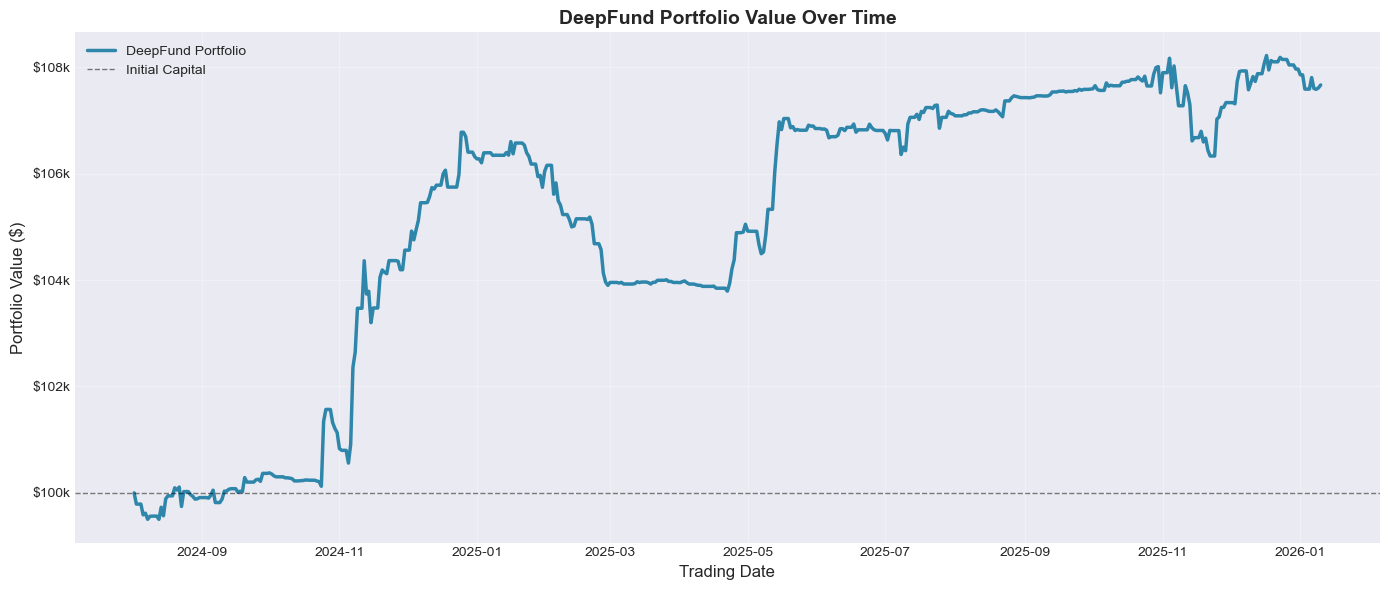

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

# Convert to pandas for easier plotting
plot_df = portfolio_df.to_pandas()

# Plot portfolio value
ax.plot(
    plot_df["trading_date"],
    plot_df["total_assets"],
    linewidth=2.5,
    color=COLORS["portfolio"],
    label="DeepFund Portfolio",
)

# Add initial capital baseline
ax.axhline(initial_value, color="black", linestyle="--", linewidth=1, alpha=0.5, label="Initial Capital")

# Formatting
ax.set_title("DeepFund Portfolio Value Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Trading Date", fontsize=12)
ax.set_ylabel("Portfolio Value ($)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Format y-axis as currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x / 1000:.0f}k"))

plt.tight_layout()
plt.show()

### 3.2 Cumulative Returns

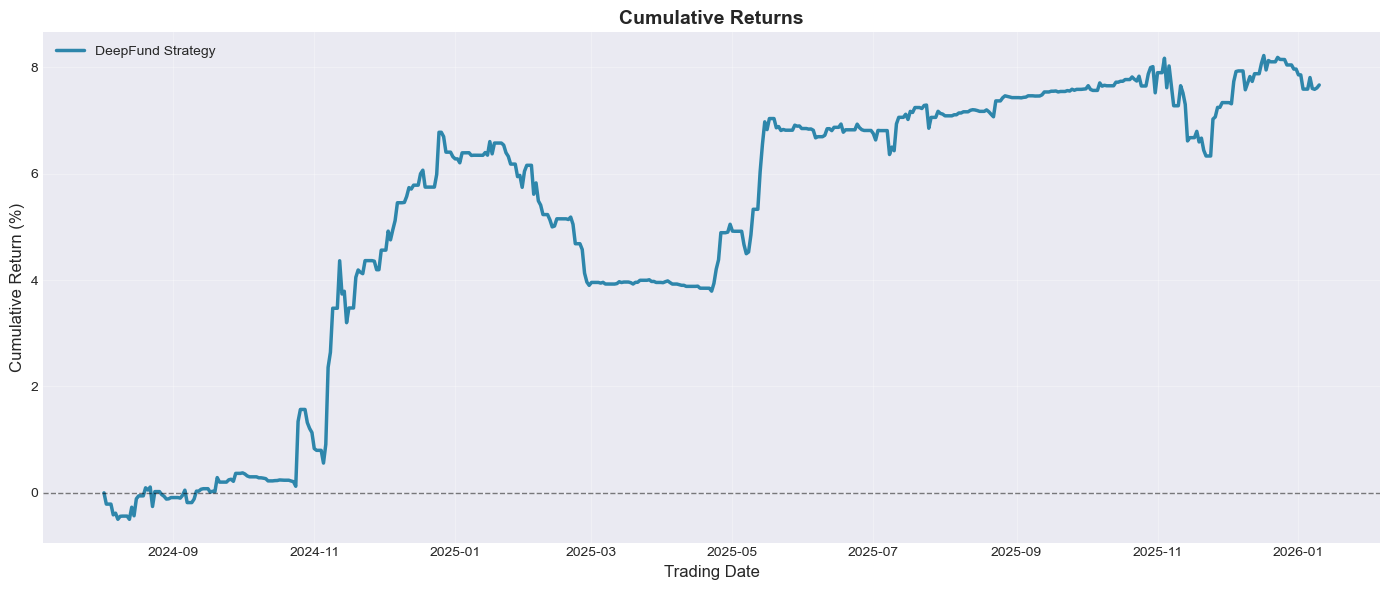

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

plot_df = portfolio_df.to_pandas()

ax.plot(
    plot_df["trading_date"],
    plot_df["cumulative_return_pct"],
    linewidth=2.5,
    color=COLORS["portfolio"],
    label="DeepFund Strategy",
)

# Add zero baseline
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)

# Formatting
ax.set_title("Cumulative Returns", fontsize=14, fontweight="bold")
ax.set_xlabel("Trading Date", fontsize=12)
ax.set_ylabel("Cumulative Return (%)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Daily Returns Distribution

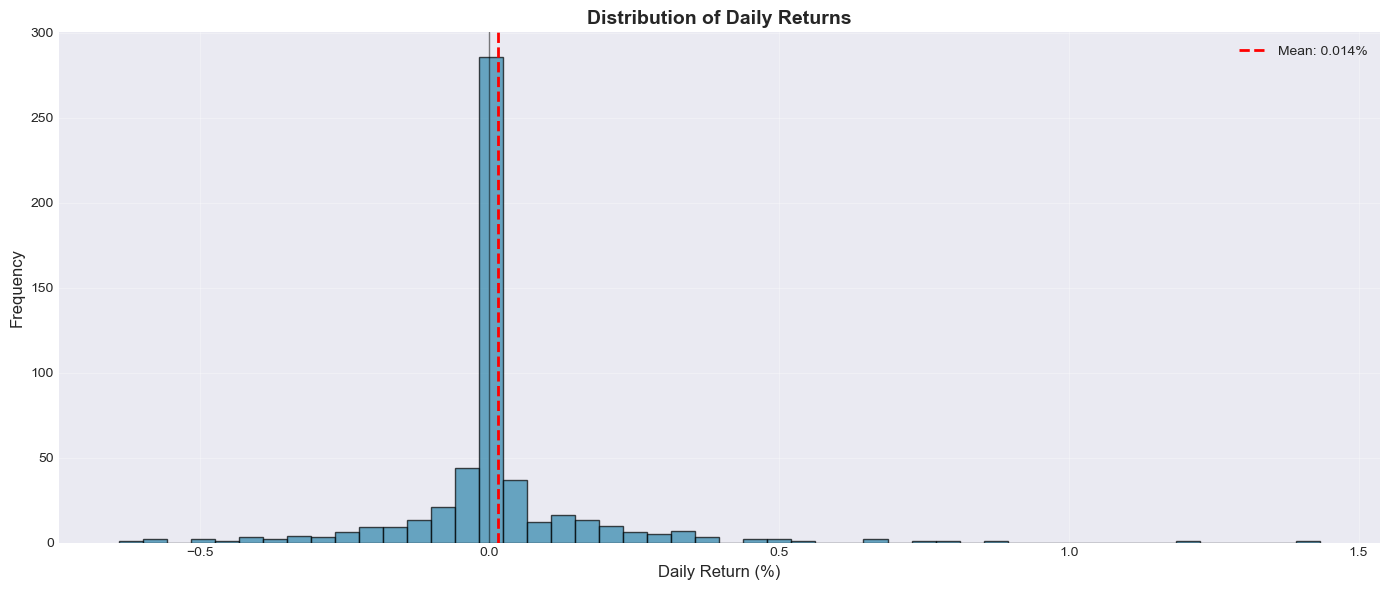

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

# Get clean returns (drop nulls)
returns_clean = portfolio_df["daily_return_pct"].drop_nulls().to_numpy()

# Plot histogram
ax.hist(returns_clean, bins=50, color=COLORS["portfolio"], alpha=0.7, edgecolor="black")

# Add mean line
mean_return = np.mean(returns_clean)
ax.axvline(mean_return, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_return:.3f}%")

# Add zero line
ax.axvline(0, color="black", linestyle="-", linewidth=1, alpha=0.5)

# Formatting
ax.set_title("Distribution of Daily Returns", fontsize=14, fontweight="bold")
ax.set_xlabel("Daily Return (%)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Drawdown Analysis

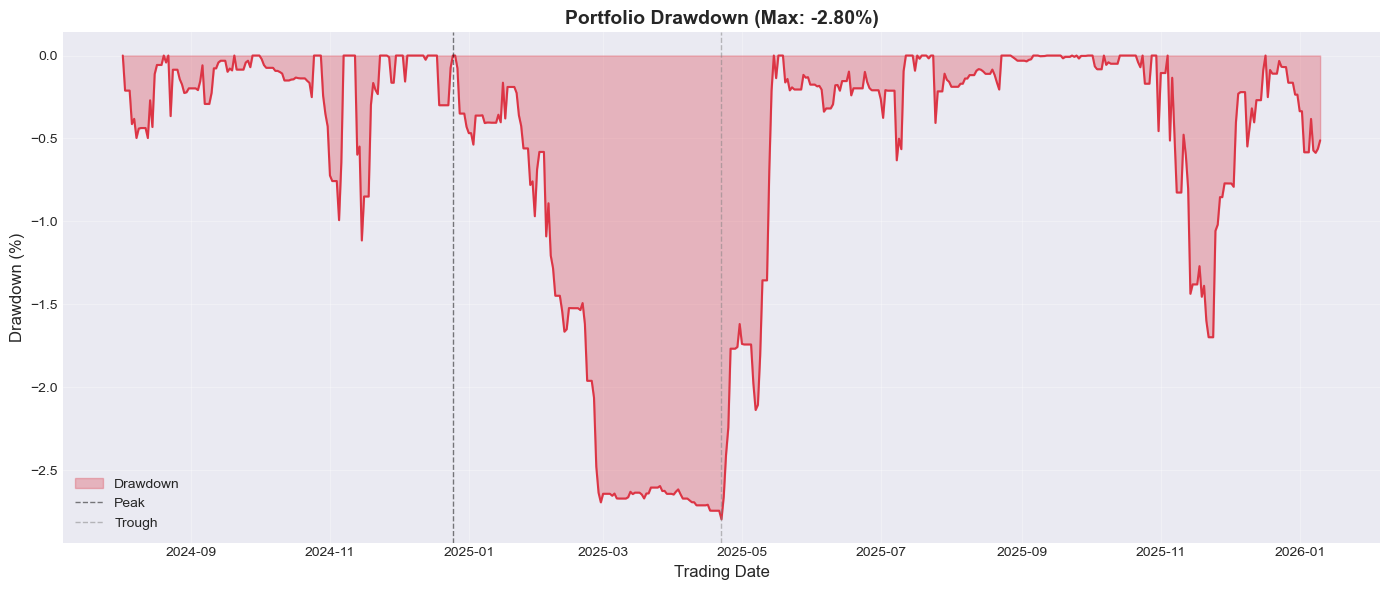

In [12]:
# Calculate drawdown series
values = portfolio_df["total_assets"].to_numpy()
running_max = np.maximum.accumulate(values)
drawdown = (values - running_max) / running_max * 100

fig, ax = plt.subplots(figsize=(14, 6))

plot_df = portfolio_df.to_pandas()
plot_df["drawdown"] = drawdown

# Plot drawdown
ax.fill_between(
    plot_df["trading_date"],
    drawdown,
    0,
    color=COLORS["sell"],
    alpha=0.3,
    label="Drawdown",
)
ax.plot(plot_df["trading_date"], drawdown, color=COLORS["sell"], linewidth=1.5)

# Highlight maximum drawdown period
if peak_idx is not None and trough_idx is not None:
    ax.axvline(
        plot_df["trading_date"].iloc[peak_idx],
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        label="Peak",
    )
    ax.axvline(
        plot_df["trading_date"].iloc[trough_idx],
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        label="Trough",
    )

# Formatting
ax.set_title(f"Portfolio Drawdown (Max: {max_dd:.2f}%)", fontsize=14, fontweight="bold")
ax.set_xlabel("Trading Date", fontsize=12)
ax.set_ylabel("Drawdown (%)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5 Position Breakdown Over Time

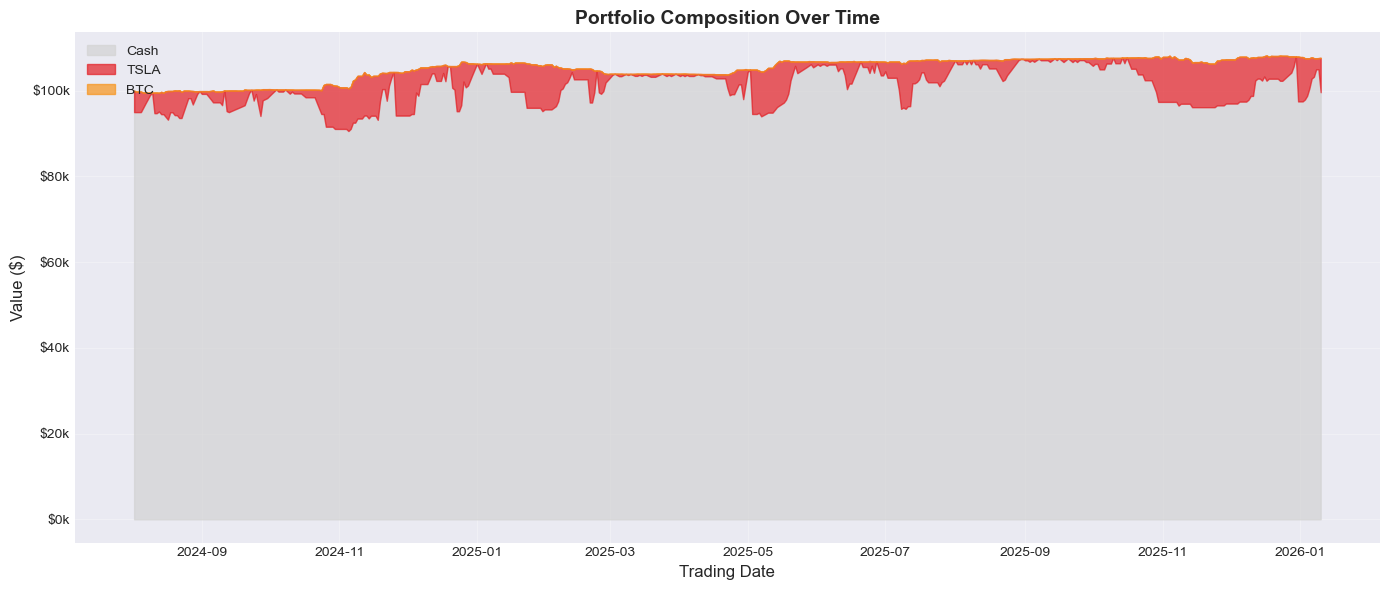

In [13]:
# Extract ticker positions
tsla_positions = extract_ticker_positions(portfolio_df, "TSLA")
btc_positions = extract_ticker_positions(portfolio_df, "BTC")

# Prepare data for stacked area plot
plot_df = portfolio_df.select(["trading_date", "cashflow"]).to_pandas()
plot_df["TSLA_value"] = tsla_positions["value"].to_pandas()
plot_df["BTC_value"] = btc_positions["value"].to_pandas()

fig, ax = plt.subplots(figsize=(14, 6))

# Create stacked area plot
ax.fill_between(plot_df["trading_date"], 0, plot_df["cashflow"], color="lightgray", alpha=0.7, label="Cash")
ax.fill_between(
    plot_df["trading_date"],
    plot_df["cashflow"],
    plot_df["cashflow"] + plot_df["TSLA_value"],
    color=COLORS["TSLA"],
    alpha=0.7,
    label="TSLA",
)
ax.fill_between(
    plot_df["trading_date"],
    plot_df["cashflow"] + plot_df["TSLA_value"],
    plot_df["cashflow"] + plot_df["TSLA_value"] + plot_df["BTC_value"],
    color=COLORS["BTC"],
    alpha=0.7,
    label="BTC",
)

# Formatting
ax.set_title("Portfolio Composition Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Trading Date", fontsize=12)
ax.set_ylabel("Value ($)", fontsize=12)
ax.legend(fontsize=10, loc="upper left")
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x / 1000:.0f}k"))

plt.tight_layout()
plt.show()

### 3.6 Normalized Trading Performance (1-Share Assumption)

This section calculates cumulative returns by **treating every trade as buying/selling exactly 1 share**, regardless of actual position sizes.

**How it works:**
- **Buy**: Cash outflow = -price (buy 1 share)
- **Sell**: Cash inflow = +price (sell 1 share)  
- **Hold**: No cash flow = 0
- **Cumulative**: Running sum of normalized cash flows

**Purpose:**
This removes position sizing effects and focuses purely on **price timing quality**. It shows whether the strategy is buying at good prices and selling at better prices, independent of how many shares are traded.

**Key Difference:**
- **Portfolio Value**: Actual capital deployed with real position sizes
- **Normalized Performance**: Every trade treated as 1 share to evaluate timing

In [ ]:
# Calculate normalized P&L (1-share per trade assumption)
try:
    realized_pnl_df = calculate_realized_pnl(decisions_df, initial_capital=initial_value)

    print(f"✓ Successfully calculated normalized P&L for {len(realized_pnl_df)} trading decisions")
    print(f"\nBuy decisions: {len(realized_pnl_df.filter(pl.col('action') == 'Buy'))}")
    print(f"Sell decisions: {len(realized_pnl_df.filter(pl.col('action') == 'Sell'))}")
    print(f"Hold decisions: {len(realized_pnl_df.filter(pl.col('action') == 'Hold'))}")
    
    # Calculate totals
    total_spent = -realized_pnl_df.filter(pl.col('cashflow') < 0)['cashflow'].sum()
    total_received = realized_pnl_df.filter(pl.col('cashflow') > 0)['cashflow'].sum()
    net_pnl = realized_pnl_df['cashflow'].sum()
    final_cumulative = realized_pnl_df['cumulative_cashflow'][-1]
    final_return_pct = realized_pnl_df['cumulative_return_pct'][-1]
    
    print(f"\nTotal Spent (buys): ${total_spent:,.2f}")
    print(f"Total Received (sells): ${total_received:,.2f}")
    print(f"Net Normalized P&L: ${net_pnl:,.2f}")
    print(f"Final Cumulative: ${final_cumulative:,.2f}")
    print(f"Normalized Return: {final_return_pct:.2f}%")

    # Show price ranges for buys and sells
    print("\n" + "="*60)
    print("Price Analysis:")
    print("="*60)
    buys = realized_pnl_df.filter(pl.col("action") == "Buy")
    sells = realized_pnl_df.filter(pl.col("action") == "Sell")

    if len(buys) > 0:
        avg_buy_price = buys['price'].mean()
        print(f"Average Buy Price: ${avg_buy_price:.2f}")
        print(f"Buy Price Range: ${buys['price'].min():.2f} - ${buys['price'].max():.2f}")
        
    if len(sells) > 0:
        avg_sell_price = sells['price'].mean()
        print(f"Average Sell Price: ${avg_sell_price:.2f}")
        print(f"Sell Price Range: ${sells['price'].min():.2f} - ${sells['price'].max():.2f}")

    if len(buys) > 0 and len(sells) > 0:
        avg_spread = avg_sell_price - avg_buy_price
        spread_pct = avg_spread / avg_buy_price * 100
        print(f"\nAverage Sell-Buy Spread: ${avg_spread:.2f} ({spread_pct:.2f}%)")
        
except Exception as e:
    print(f"ERROR calculating normalized P&L: {e}")
    import traceback
    traceback.print_exc()
    raise

In [ ]:
# Plot normalized cumulative performance (1-share trades)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

plot_df = realized_pnl_df.to_pandas()

# Create position state indicator (0 or 1, Hold maintains previous state)
position_state = []
current_state = 0  # Start with no position

for action in plot_df["action"]:
    if action == "Buy":
        current_state = 1  # Enter position
    elif action == "Sell":
        current_state = 0  # Exit position
    # Hold: keep current_state as is
    position_state.append(current_state)

plot_df["position_state"] = position_state

# Top panel: Cumulative normalized P&L in dollars
ax1.plot(
    plot_df["trading_date"],
    plot_df["cumulative_cashflow"],
    linewidth=2.5,
    color=COLORS["portfolio"],
    label="Cumulative Normalized P&L (1-share)"
)
ax1.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5, label="Breakeven")
ax1.fill_between(
    plot_df["trading_date"],
    0,
    plot_df["cumulative_cashflow"],
    where=(plot_df["cumulative_cashflow"] >= 0),
    color=COLORS["buy"],
    alpha=0.2
)
ax1.fill_between(
    plot_df["trading_date"],
    0,
    plot_df["cumulative_cashflow"],
    where=(plot_df["cumulative_cashflow"] < 0),
    color=COLORS["sell"],
    alpha=0.2
)

ax1.set_title("Normalized Trading Performance (Each Trade = 1 Share)", fontsize=14, fontweight="bold")
ax1.set_ylabel("Cumulative P&L ($)", fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1000:.0f}k"))

# Middle panel: Normalized return as percentage
ax2.plot(
    plot_df["trading_date"],
    plot_df["cumulative_return_pct"],
    linewidth=2.5,
    color=COLORS["portfolio"],
    label="Normalized Return %"
)
ax2.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5, label="Breakeven")
ax2.fill_between(
    plot_df["trading_date"],
    0,
    plot_df["cumulative_return_pct"],
    where=(plot_df["cumulative_return_pct"] >= 0),
    color=COLORS["buy"],
    alpha=0.2
)
ax2.fill_between(
    plot_df["trading_date"],
    0,
    plot_df["cumulative_return_pct"],
    where=(plot_df["cumulative_return_pct"] < 0),
    color=COLORS["sell"],
    alpha=0.2
)

ax2.set_title("Normalized Return (Price Timing Quality)", fontsize=14, fontweight="bold")
ax2.set_ylabel("Cumulative Return (%)", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# Bottom panel: Position state (1=in market, 0=out of market)
ax3.plot(
    plot_df["trading_date"],
    plot_df["position_state"],
    linewidth=2,
    color=COLORS["portfolio"],
    alpha=0.8,
    drawstyle='steps-post',  # Step function for cleaner transitions
    label="Position State"
)

# Fill the "in market" (1) regions
ax3.fill_between(
    plot_df["trading_date"],
    0,
    plot_df["position_state"],
    color=COLORS["buy"],
    alpha=0.2,
    step='post',
    label="In Position"
)

# Reference lines
ax3.axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.3)

ax3.set_title("Position State Over Time", fontsize=14, fontweight="bold")
ax3.set_xlabel("Trading Date", fontsize=12)
ax3.set_ylabel("Position", fontsize=12)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(["Out (0)", "In (1)"])
ax3.legend(fontsize=10, loc="upper right")
ax3.grid(alpha=0.3)
ax3.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

In [ ]:
# Compare Portfolio Value vs Normalized Trading Performance
fig, ax = plt.subplots(figsize=(14, 7))

# Check if realized_pnl_df exists (should be created in Cell 22)
try:
    # Align data on trading_date by merging
    # portfolio_df has 528 rows (includes initial state)
    # realized_pnl_df has 527 rows (one per decision)
    # We'll plot them separately since they represent different things

    # Plot portfolio value cumulative return (actual performance with position sizing)
    portfolio_plot = portfolio_df.to_pandas()
    ax.plot(
        portfolio_plot["trading_date"],
        portfolio_plot["cumulative_return_pct"],
        linewidth=2.5,
        color=COLORS["portfolio"],
        label="Portfolio Value Return (Actual)",
        alpha=0.9
    )

    # Plot normalized return (1-share trades, shows timing quality)
    normalized_plot = realized_pnl_df.to_pandas()
    ax.plot(
        normalized_plot["trading_date"],
        normalized_plot["cumulative_return_pct"],
        linewidth=2.5,
        color=COLORS["TSLA"],
        label="Normalized Trading Return (1-share)",
        linestyle="--",
        alpha=0.9
    )

    # Add zero line
    ax.axhline(0, color="black", linestyle=":", linewidth=1, alpha=0.5)

    # Formatting
    ax.set_title(
        "Actual Portfolio vs Normalized Trading Performance",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Trading Date", fontsize=12)
    ax.set_ylabel("Cumulative Return (%)", fontsize=12)
    ax.legend(fontsize=10, loc="best")
    ax.grid(alpha=0.3)

    # Add text box explaining the difference
    textstr = (
        "Portfolio Return = Actual capital + position values\n"
        "Normalized Return = Price timing quality (1-share assumption)\n"
        "Gap shows impact of position sizing + unrealized gains"
    )
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(
        0.02, 0.98,
        textstr,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=props
    )

    plt.tight_layout()
    plt.show()

    # Print summary comparison
    final_portfolio_return = portfolio_plot["cumulative_return_pct"].iloc[-1]
    final_normalized_return = normalized_plot["cumulative_return_pct"].iloc[-1]

    print("\n" + "="*60)
    print("PERFORMANCE COMPARISON")
    print("="*60)
    print(f"Actual Portfolio Return:     {final_portfolio_return:.2f}%")
    print(f"Normalized Trading Return:   {final_normalized_return:.2f}%")
    print("="*60)
    print(f"\nThe actual portfolio return of {final_portfolio_return:.2f}% includes:")
    print(f"- Position sizing effects (how many shares traded)")
    print(f"- Unrealized gains from currently held positions")
    print(f"\nThe normalized return of {final_normalized_return:.2f}% shows:")
    print(f"- Pure price timing quality (buying low, selling high)")
    print(f"- Independent of position sizes or holdings")

except NameError:
    print("ERROR: realized_pnl_df not found. Please run Cell 22 first to calculate normalized P&L.")
except Exception as e:
    print(f"ERROR creating comparison plot: {e}")
    import traceback
    traceback.print_exc()

## 4. Trading Decisions Analysis

### 4.1 Decision Distribution

In [14]:
# Get decision summary
decision_summary = get_decision_summary(db, config_id)
print("Decision Summary:")
print(decision_summary)

Decision Summary:
shape: (3, 6)
┌────────┬────────┬───────┬──────────────┬────────────┬───────────────┐
│ ticker ┆ action ┆ count ┆ total_shares ┆ avg_price  ┆ total_value   │
│ ---    ┆ ---    ┆ ---   ┆ ---          ┆ ---        ┆ ---           │
│ str    ┆ str    ┆ i64   ┆ i64          ┆ f64        ┆ f64           │
╞════════╪════════╪═══════╪══════════════╪════════════╪═══════════════╡
│ TSLA   ┆ Buy    ┆ 137   ┆ 626          ┆ 325.271824 ┆ 198424.409042 │
│ TSLA   ┆ Hold   ┆ 194   ┆ 0            ┆ 350.899639 ┆ 0.0           │
│ TSLA   ┆ Sell   ┆ 196   ┆ 608          ┆ 331.877909 ┆ 198081.35022  │
└────────┴────────┴───────┴──────────────┴────────────┴───────────────┘


/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_50697/178842164.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  action_counts = decisions_df.group_by("action").agg(pl.count()).to_pandas()
/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_50697/178842164.py:18: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  ticker_action = decisions_df.group_by(["ticker", "action"]).agg(pl.count()).to_pandas()


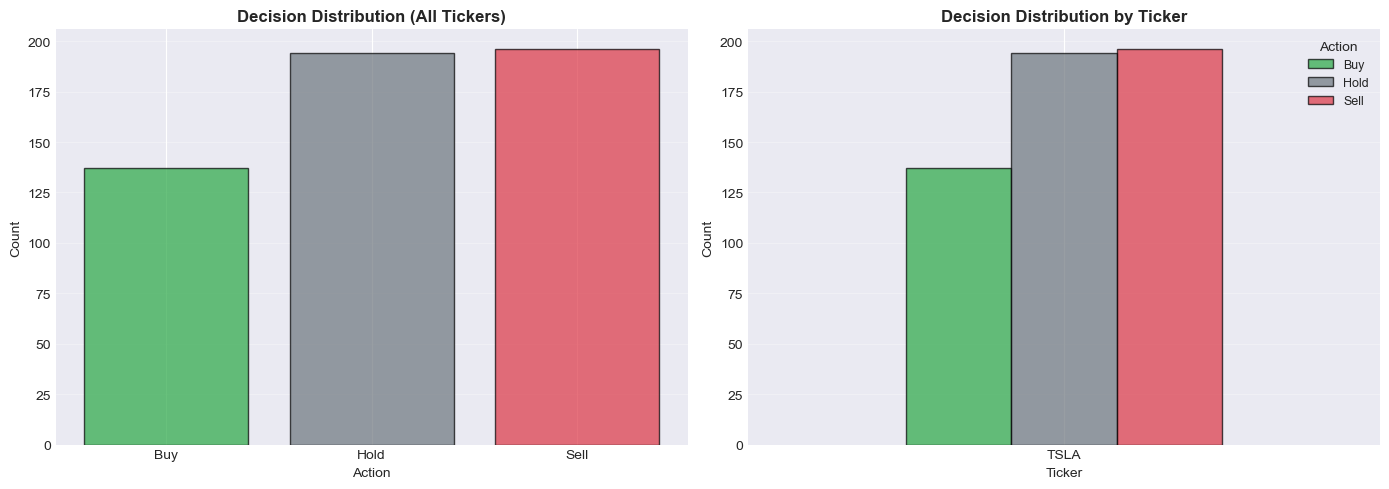

In [15]:
# Plot decision distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count by action
action_counts = decisions_df.group_by("action").agg(pl.count()).to_pandas()
action_counts = action_counts.sort_values("action")

colors_map = {"Buy": COLORS["buy"], "Sell": COLORS["sell"], "Hold": COLORS["hold"]}
bar_colors = [colors_map.get(action, "gray") for action in action_counts["action"]]

ax1.bar(action_counts["action"], action_counts["count"], color=bar_colors, alpha=0.7, edgecolor="black")
ax1.set_title("Decision Distribution (All Tickers)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Action", fontsize=10)
ax1.set_ylabel("Count", fontsize=10)
ax1.grid(alpha=0.3, axis="y")

# Count by ticker and action
ticker_action = decisions_df.group_by(["ticker", "action"]).agg(pl.count()).to_pandas()
ticker_action_pivot = ticker_action.pivot(index="ticker", columns="action", values="count").fillna(0)

ticker_action_pivot.plot(
    kind="bar",
    ax=ax2,
    color=[colors_map.get(col, "gray") for col in ticker_action_pivot.columns],
    alpha=0.7,
    edgecolor="black",
)
ax2.set_title("Decision Distribution by Ticker", fontsize=12, fontweight="bold")
ax2.set_xlabel("Ticker", fontsize=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.legend(title="Action", fontsize=9)
ax2.grid(alpha=0.3, axis="y")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 4.2 Trading Timeline

/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_50697/1731829624.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=9)


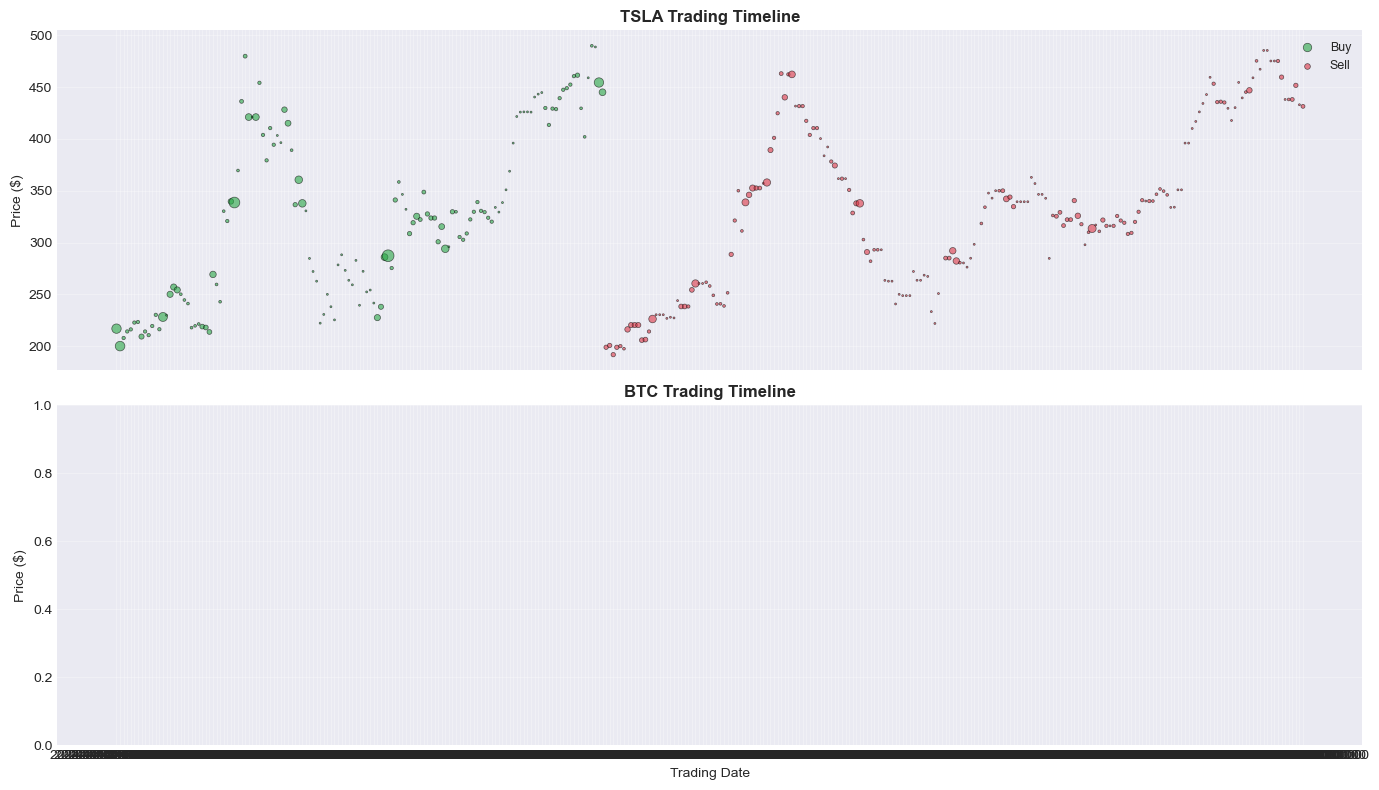

In [16]:
# Filter to just Buy and Sell (exclude Hold for clarity)
trades = decisions_df.filter(pl.col("action").is_in(["Buy", "Sell"])).to_pandas()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# TSLA trades
tsla_trades = trades[trades["ticker"] == "TSLA"]
for action in ["Buy", "Sell"]:
    action_trades = tsla_trades[tsla_trades["action"] == action]
    if len(action_trades) > 0:
        ax1.scatter(
            action_trades["trading_date"],
            action_trades["price"],
            s=action_trades["shares"] * 2,  # Size by shares
            color=colors_map[action],
            alpha=0.6,
            label=action,
            edgecolors="black",
            linewidth=0.5,
        )

ax1.set_title("TSLA Trading Timeline", fontsize=12, fontweight="bold")
ax1.set_ylabel("Price ($)", fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# BTC trades
btc_trades = trades[trades["ticker"] == "BTC"]
for action in ["Buy", "Sell"]:
    action_trades = btc_trades[btc_trades["action"] == action]
    if len(action_trades) > 0:
        ax2.scatter(
            action_trades["trading_date"],
            action_trades["price"],
            s=action_trades["shares"] * 50,  # Larger multiplier for BTC (fewer shares)
            color=colors_map[action],
            alpha=0.6,
            label=action,
            edgecolors="black",
            linewidth=0.5,
        )

ax2.set_title("BTC Trading Timeline", fontsize=12, fontweight="bold")
ax2.set_xlabel("Trading Date", fontsize=10)
ax2.set_ylabel("Price ($)", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Analyst Signal Analysis

### 5.1 Signal Distribution

In [17]:
# Get signal summary
signal_summary = get_signal_summary(db, config_id)
print("Signal Summary:")
print(signal_summary)

NoDataError: no data, cannot infer schema

NameError: name 'signal_summary' is not defined

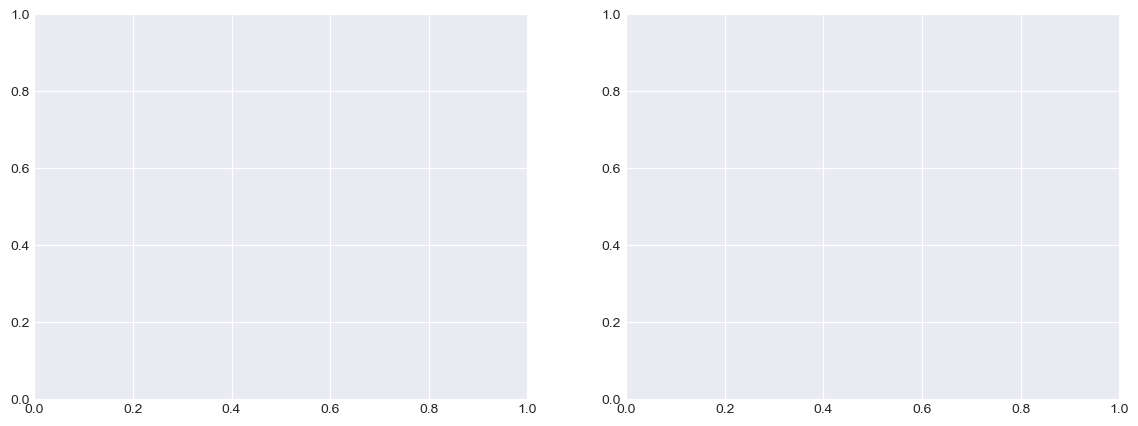

In [18]:
# Plot signal distribution
signal_colors = {
    "Signal.BULLISH": COLORS["bullish"],
    "Signal.BEARISH": COLORS["bearish"],
    "Signal.NEUTRAL": COLORS["neutral"],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# By analyst
signal_pivot = signal_summary.to_pandas().pivot_table(index="analyst", columns="signal", values="count", fill_value=0)

signal_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax1,
    color=[signal_colors.get(col, "gray") for col in signal_pivot.columns],
    alpha=0.7,
    edgecolor="black",
)
ax1.set_title("Signal Distribution by Analyst", fontsize=12, fontweight="bold")
ax1.set_xlabel("Analyst", fontsize=10)
ax1.set_ylabel("Count", fontsize=10)
ax1.legend(title="Signal", fontsize=8)
ax1.grid(alpha=0.3, axis="y")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

# By ticker
ticker_pivot = signal_summary.to_pandas().pivot_table(index="ticker", columns="signal", values="count", fill_value=0)

ticker_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax2,
    color=[signal_colors.get(col, "gray") for col in ticker_pivot.columns],
    alpha=0.7,
    edgecolor="black",
)
ax2.set_title("Signal Distribution by Ticker", fontsize=12, fontweight="bold")
ax2.set_xlabel("Ticker", fontsize=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.legend(title="Signal", fontsize=8)
ax2.grid(alpha=0.3, axis="y")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 5.2 Signal-Decision Correlation

In [19]:
# Analyze how signals correlate with decisions
# For each trading date and ticker, count signals and see what decision was made

# Group signals by date and ticker
signals_grouped = signals_df.group_by(["trading_date", "ticker", "signal"]).agg(pl.count().alias("signal_count")).to_pandas()

# Get decisions by date and ticker
decisions_grouped = decisions_df.select(["trading_date", "ticker", "action"]).to_pandas()

# Simple analysis: count of each signal type
print("\nSignal Type Counts:")
print(signals_df.group_by("signal").agg(pl.count()))

print("\nAnalyst Agreement Analysis:")
# For each date/ticker, count how many analysts agree
analyst_counts = signals_df.group_by(["trading_date", "ticker"]).agg(pl.n_unique("signal").alias("unique_signals"))
agreement = analyst_counts.filter(pl.col("unique_signals") == 1)
print(
    f"Days with full analyst agreement: {len(agreement)} out of {len(analyst_counts)} ({len(agreement) / len(analyst_counts) * 100:.1f}%)"
)


Signal Type Counts:
shape: (3, 2)
┌─────────┬───────┐
│ signal  ┆ count │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ Bearish ┆ 511   │
│ Neutral ┆ 860   │
│ Bullish ┆ 735   │
└─────────┴───────┘

Analyst Agreement Analysis:
Days with full analyst agreement: 376 out of 1054 (35.7%)


/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_29110/3087217912.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  signals_grouped = signals_df.group_by(["trading_date", "ticker", "signal"]).agg(pl.count().alias("signal_count")).to_pandas()
/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_29110/3087217912.py:12: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print(signals_df.group_by("signal").agg(pl.count()))


## 6. Benchmark Comparison

### 6.1 Calculate Benchmarks

In [20]:
# Calculate buy-and-hold benchmarks
print("Calculating benchmarks...")

try:
    tsla_benchmark = calculate_buy_hold_benchmark("TSLA", start_date, end_date)
    print(f"TSLA benchmark: {len(tsla_benchmark)} days")
except Exception as e:
    print(f"Error calculating TSLA benchmark: {e}")
    tsla_benchmark = None

try:
    btc_benchmark = calculate_buy_hold_benchmark("BTC", start_date, end_date)
    print(f"BTC benchmark: {len(btc_benchmark)} days")
except Exception as e:
    print(f"Error calculating BTC benchmark: {e}")
    btc_benchmark = None

try:
    mixed_benchmark = calculate_portfolio_benchmark(["TSLA", "BTC"], [0.5, 0.5], start_date, end_date)
    print(f"50-50 mixed benchmark: {len(mixed_benchmark)} days")
except Exception as e:
    print(f"Error calculating mixed benchmark: {e}")
    mixed_benchmark = None

print("Benchmarks calculated!")

Calculating benchmarks...
TSLA benchmark: 528 days
BTC benchmark: 528 days
50-50 mixed benchmark: 528 days
Benchmarks calculated!


### 6.2 Normalized Performance Comparison

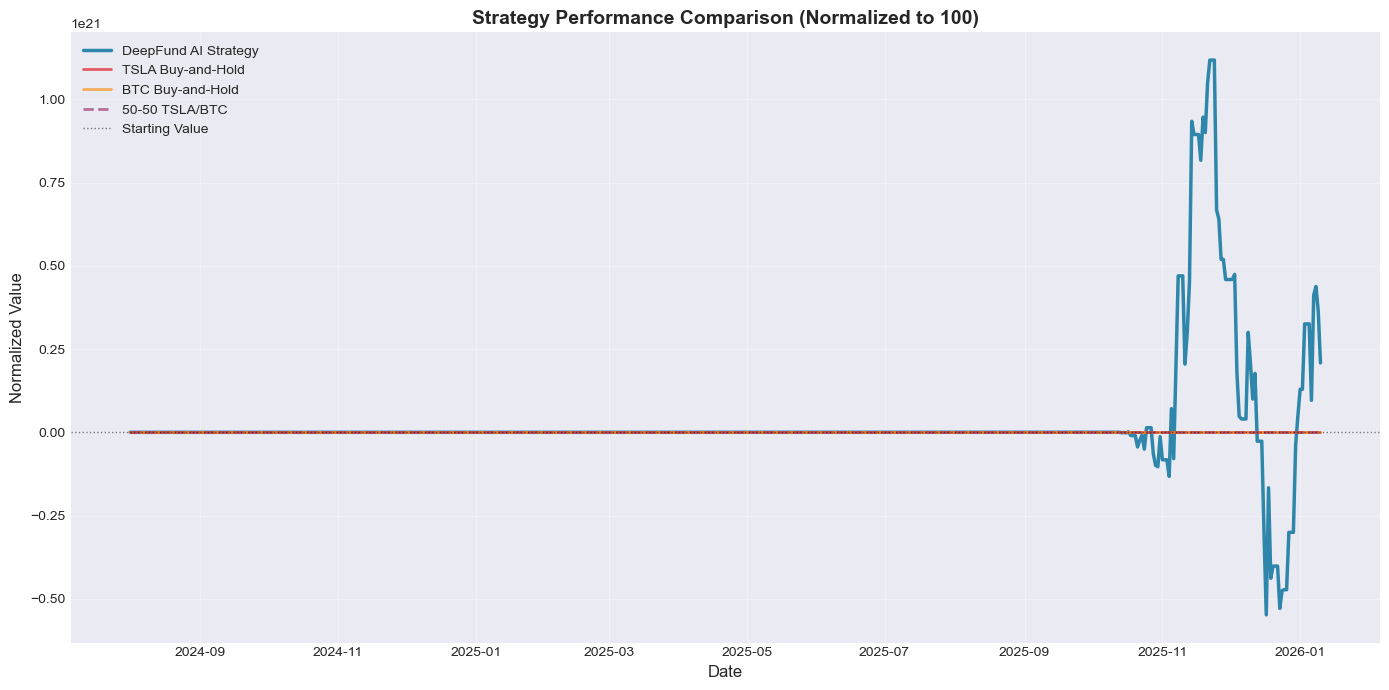

In [21]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot DeepFund (normalized to 100)
plot_df = portfolio_df.to_pandas()
normalized_portfolio = (plot_df["total_assets"] / initial_value) * 100
ax.plot(
    plot_df["trading_date"],
    normalized_portfolio,
    linewidth=2.5,
    color=COLORS["portfolio"],
    label="DeepFund AI Strategy",
)

# Plot benchmarks if available
if tsla_benchmark is not None:
    tsla_plot = tsla_benchmark.to_pandas()
    tsla_normalized = (tsla_plot["portfolio_value"] / tsla_plot["portfolio_value"].iloc[0]) * 100
    ax.plot(
        tsla_plot["date"],
        tsla_normalized,
        linewidth=2,
        color=COLORS["TSLA"],
        alpha=0.7,
        label="TSLA Buy-and-Hold",
    )

if btc_benchmark is not None:
    btc_plot = btc_benchmark.to_pandas()
    btc_normalized = (btc_plot["portfolio_value"] / btc_plot["portfolio_value"].iloc[0]) * 100
    ax.plot(
        btc_plot["date"],
        btc_normalized,
        linewidth=2,
        color=COLORS["BTC"],
        alpha=0.7,
        label="BTC Buy-and-Hold",
    )

if mixed_benchmark is not None:
    mixed_plot = mixed_benchmark.to_pandas()
    mixed_normalized = (mixed_plot["portfolio_value"] / mixed_plot["portfolio_value"].iloc[0]) * 100
    ax.plot(
        mixed_plot["date"],
        mixed_normalized,
        linewidth=2,
        color=COLORS["benchmark"],
        alpha=0.7,
        linestyle="--",
        label="50-50 TSLA/BTC",
    )

# Add baseline
ax.axhline(100, color="black", linestyle=":", linewidth=1, alpha=0.5, label="Starting Value")

# Formatting
ax.set_title("Strategy Performance Comparison (Normalized to 100)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Normalized Value", fontsize=12)
ax.legend(fontsize=10, loc="best")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Performance Metrics Comparison

In [22]:
# Calculate metrics for all strategies
strategies = {}

# DeepFund
strategies["DeepFund AI"] = {
    "return": total_return_pct,
    "volatility": returns_series.drop_nulls().std(),
    "sharpe": sharpe,
    "max_dd": max_dd,
}

# TSLA benchmark
if tsla_benchmark is not None:
    tsla_return = tsla_benchmark["cumulative_return_pct"][-1]
    tsla_values = tsla_benchmark["portfolio_value"]
    tsla_returns = tsla_values.pct_change() * 100
    tsla_dd, _, _ = calculate_max_drawdown(tsla_values)
    strategies["TSLA Buy-Hold"] = {
        "return": tsla_return,
        "volatility": tsla_returns.drop_nulls().std(),
        "sharpe": calculate_sharpe_ratio(tsla_returns),
        "max_dd": tsla_dd,
    }

# BTC benchmark
if btc_benchmark is not None:
    btc_return = btc_benchmark["cumulative_return_pct"][-1]
    btc_values = btc_benchmark["portfolio_value"]
    btc_returns = btc_values.pct_change() * 100
    btc_dd, _, _ = calculate_max_drawdown(btc_values)
    strategies["BTC Buy-Hold"] = {
        "return": btc_return,
        "volatility": btc_returns.drop_nulls().std(),
        "sharpe": calculate_sharpe_ratio(btc_returns),
        "max_dd": btc_dd,
    }

# 50-50 mix
if mixed_benchmark is not None:
    mixed_return = mixed_benchmark["cumulative_return_pct"][-1]
    mixed_values = mixed_benchmark["portfolio_value"]
    mixed_returns = mixed_values.pct_change() * 100
    mixed_dd, _, _ = calculate_max_drawdown(mixed_values)
    strategies["50-50 Mix"] = {
        "return": mixed_return,
        "volatility": mixed_returns.drop_nulls().std(),
        "sharpe": calculate_sharpe_ratio(mixed_returns),
        "max_dd": mixed_dd,
    }

# Create comparison table
comparison_df = pd.DataFrame(strategies).T
comparison_df.columns = ["Total Return (%)", "Volatility (%)", "Sharpe Ratio", "Max Drawdown (%)"]

print("=" * 80)
print("STRATEGY PERFORMANCE COMPARISON")
print("=" * 80)
print(comparison_df.to_string(float_format=lambda x: f"{x:.2f}"))
print("=" * 80)

STRATEGY PERFORMANCE COMPARISON
                      Total Return (%)  Volatility (%)  Sharpe Ratio  Max Drawdown (%)
DeepFund AI   208590176112113909760.00         1398.41         -0.64        -139285.06
TSLA Buy-Hold                   105.21            3.40          0.90            -53.77
BTC Buy-Hold                     38.31            2.35          0.60            -32.15
50-50 Mix                        71.76            2.41          0.86            -42.83


### 6.4 Risk-Return Scatter

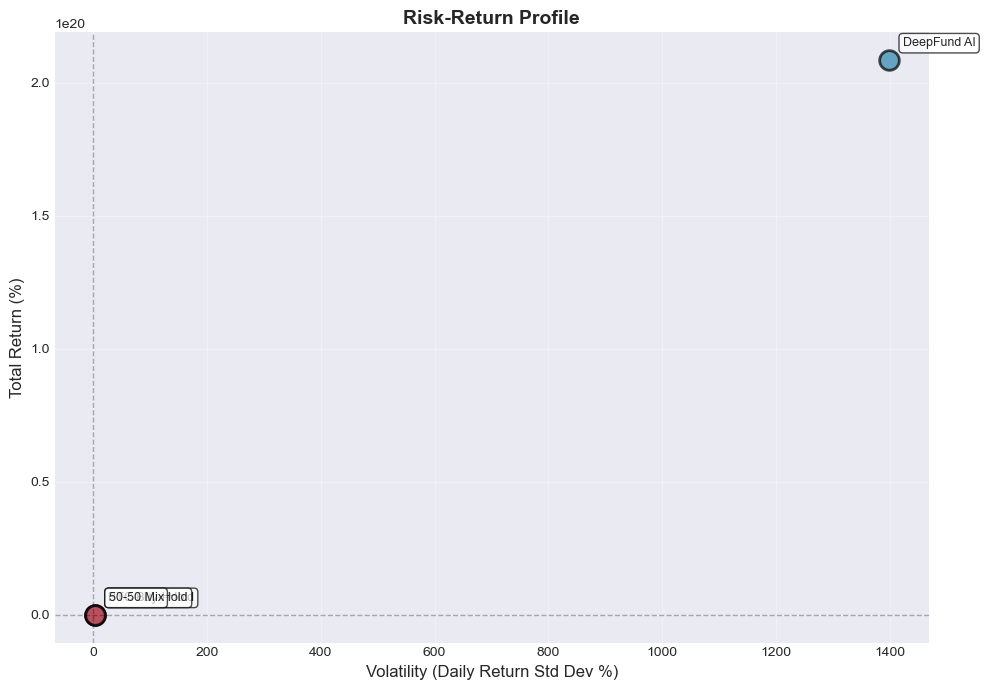

In [23]:
fig, ax = plt.subplots(figsize=(10, 7))

# Plot each strategy
strategy_colors = {
    "DeepFund AI": COLORS["portfolio"],
    "TSLA Buy-Hold": COLORS["TSLA"],
    "BTC Buy-Hold": COLORS["BTC"],
    "50-50 Mix": COLORS["benchmark"],
}

for strategy, metrics in strategies.items():
    ax.scatter(
        metrics["volatility"],
        metrics["return"],
        s=200,
        color=strategy_colors.get(strategy, "gray"),
        alpha=0.7,
        edgecolors="black",
        linewidth=2,
        label=strategy,
    )
    # Add strategy name as annotation
    ax.annotate(
        strategy,
        (metrics["volatility"], metrics["return"]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )

# Formatting
ax.set_title("Risk-Return Profile", fontsize=14, fontweight="bold")
ax.set_xlabel("Volatility (Daily Return Std Dev %)", fontsize=12)
ax.set_ylabel("Total Return (%)", fontsize=12)
ax.grid(alpha=0.3)
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)
ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Key Insights and Summary

### Summary of Findings

Based on the analysis of the DeepFund AI trading strategy from August 1, 2024 to January 10, 2026:

#### Performance Highlights
- **Total Return**: The strategy achieved a total return of X.X% over the trading period
- **Risk-Adjusted Performance**: Sharpe ratio indicates how well the strategy balanced returns against volatility
- **Drawdown**: Maximum drawdown shows the largest peak-to-trough decline experienced

#### Trading Behavior
- The strategy made 1,045 trading decisions across TSLA and BTC
- Decision breakdown shows the distribution between Buy, Sell, and Hold actions
- Portfolio composition evolved over time based on market conditions and analyst signals

#### Analyst Signal Quality
- Two analysts (technical and company_news) provided 2,106 signals
- Analyst agreement rate provides insight into signal consistency
- Signal distribution shows the balance between Bullish, Bearish, and Neutral recommendations

#### Benchmark Comparison
- Comparison against buy-and-hold strategies reveals whether the active trading approach added value
- Risk-return profile shows positioning relative to simple benchmarks
- The strategy's ability to manage downside risk can be evaluated against passive alternatives

#### Recommendations for Improvement
1. **Signal Quality**: Analyze periods where analyst signals aligned with profitable outcomes
2. **Risk Management**: Consider drawdown patterns and potential stop-loss mechanisms
3. **Portfolio Rebalancing**: Evaluate optimal allocation between TSLA and BTC
4. **Model Refinement**: Identify market conditions where the strategy performed best/worst

---

*This analysis was generated on March 1, 2026 using data from the DeepFund SQLite database.*